# Representative UMAP of BICAN April 2026 freeze data

A demo to show off the new `cellarium.ml.api` module, streamlining interactive work.

Stephen Fleming

2026.09.25

Can run on a laptop, but if using GCS bucket files, much better to run on a google VM due to network bandwidth.

Without localizing files, takes 3 hours to run HVGs on my laptop on my home internet. Takes ~10 mins on a google VM.

If you can download all the h5ad files locally, all of this will be much faster.

## Specify data location

The way this demo works is by pointing at a google bucket with h5ad files.
If you have a list of h5ad files anywhere else, you can simply input the paths as a list for the `h5ad_paths` when instantiating `CellariumData`.

This is a data extract created by Cellarium Nexus, containing 3.86M cells.

In [1]:
h5ad_base_path = "gs://cellarium-nexus-file-system-3293a8/pipeline/data-extracts/bican_202604_fullextract/extract_files"

In [2]:
# can choose whether to run on CPU or MPS or CUDA

ACCELERATOR = "cuda"  # should be in ["cpu", "mps", "cuda"]

## Imports

In [3]:
import scanpy as sc

sc.set_figure_params(fontsize=14, vector_friendly=True)

from cellarium.ml.api import h5ad_paths_from_google_bucket, CellariumData
from cellarium.ml.api.preprocessing import highly_variable_genes
from cellarium.ml.api.tools import pca, geometric_sketch

/home/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data setup

In [7]:
short_h5ads = [
    h5ad_base_path + f"/extract_0000{i:02}.h5ad"
    for i in range(25)
]

In [9]:
# set up datamodule: can take a minute for hundreds of files

cdata = CellariumData(
    # h5ad_paths=h5ad_paths_from_google_bucket(h5ad_base_path),
    h5ad_paths=short_h5ads,
    total_mrna_umis_column="n_counts",
    var_key="gene_name",
    datamodule_num_workers=12,
    accelerator=ACCELERATOR,
)
cdata

Reading n_obs from h5ad files: 100%|██████████| 2/2 [00:00<00:00,  3.43file/s]


CellariumData(shape [250000, 38094], obsm keys: [], hvg_set=False)

## Highly variable gene selection

In [10]:
# run highly variable gene selection

hvg_df, hvg_module = highly_variable_genes(
    cdata,
    n_top_genes=4000,
    flavor="seurat",
    accelerator=ACCELERATOR,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


/home/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/lightning/pytorch/loops/utilities.py:73: `max_epochs` was not set. Setting it to 1000 epochs. To train without an epoch limit, set `max_epochs=-1`.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/lightning/pytorch/core/optimizer.py:183: `LightningModule.configure_optimizers` returned `None`, this fit will run with no optimizer

  | Name     | Type              | Params | Mode 
-------------------------------------------------------
0 | pipeline | CellariumPipeline | 1      | train
-------------------------------------------------------
1         Trainable params
0         Non-trainable params
1         Total params
0.000     Total estimated model params size (MB)
5         Modules in train mode
0         Modules in eval mode


/home/sfleming/cellarium-ml/cellarium/ml/utilities/distributed.py:52: UserWarning: Distributed package is available but the default process group has not been initialized. Falling back to ``rank=0`` and ``num_replicas=1``.
  warnings.warn(
/home/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py:106: Total length of `DataLoader` across ranks is zero. Please make sure this was your intention.
/home/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py:123: Your `IterableDataset` has `__len__` defined. In combination with multi-process data loading (when num_workers > 1), `__len__` could be inaccurate if each worker is not configured independently to avoid having duplicate data.


Epoch 0:   0%|          | 0/62 [00:00<?, ?it/s] 

/home/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/torch/multiprocessing/reductions.py:473: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  return torch.sparse_compressed_tensor(


Epoch 0: 100%|██████████| 62/62 [00:56<00:00,  1.09it/s]


In [11]:
# a side-effect of running highly_variable_genes is that cdata.hvg stores the result

cdata.hvg

A1BG           False
A1BG-AS1       False
A1CF           False
A2M             True
A2M-AS1        False
               ...  
TRAJ60         False
FAM90A23       False
IGHVII-44-2    False
PRR23D2        False
TRGJP          False
Name: highly_variable, Length: 38094, dtype: bool

In [13]:
cdata.hvg.sum()

4000

In [12]:
# the result is also in hvg_df

hvg_df

,means,dispersions,mean_bin,dispersions_norm,highly_variable
A1BG,1.499301e-02,-0.811548,"(-0.00189, 0.0947]",-0.282761,False
A1BG-AS1,3.278887e-02,-0.737078,"(-0.00189, 0.0947]",-0.094097,False
A1CF,1.716719e-03,-1.074786,"(-0.00189, 0.0947]",-0.949661,False
A2M,6.170811e-02,0.569799,"(-0.00189, 0.0947]",3.216807,True
A2M-AS1,2.748391e-02,-0.596607,"(-0.00189, 0.0947]",0.261779,False
...,...,...,...,...,...
TRAJ60,1.000000e-12,NaN,"(-0.00189, 0.0947]",NaN,False
FAM90A23,1.000000e-12,NaN,"(-0.00189, 0.0947]",NaN,False
IGHVII-44-2,1.000000e-12,NaN,"(-0.00189, 0.0947]",NaN,False
PRR23D2,1.000000e-12,NaN,"(-0.00189, 0.0947]",NaN,False


## PCA

In [14]:
# run PCA

pca_module = pca(
    cdata,
    n_components=50,
    onepass_module=hvg_module,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/lightning/pytorch/loops/utilities.py:73: `max_epochs` was not set. Setting it to 1000 epochs. To train without an epoch limit, set `max_epochs=-1`.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/lightning/pytorch/core/optimizer.py:183: `LightningModule.configure_optimizers` returned `None`, this fit will run with no optimizer

  | Name     | Type              | Params | Mode 
-------------------------------------------------------
0 | pipeline | CellariumPipeline | 1      | train
-------------------------------------------------------
1         Trainable params
0         Non-trainable params
1         Total params
0.000     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode


/home/sfleming/cellarium-ml/cellarium/ml/utilities/distributed.py:52: UserWarning: Distributed package is available but the default process group has not been initialized. Falling back to ``rank=0`` and ``num_replicas=1``.
  warnings.warn(
/home/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py:106: Total length of `DataLoader` across ranks is zero. Please make sure this was your intention.
/home/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py:123: Your `IterableDataset` has `__len__` defined. In combination with multi-process data loading (when num_workers > 1), `__len__` could be inaccurate if each worker is not configured independently to avoid having duplicate data.


Epoch 0: 100%|██████████| 62/62 [00:55<00:00,  1.12it/s]


In [16]:
pca_module

CellariumModule(pipeline = CellariumPipeline(
  (0): Filter(filter_list=['A2M' 'ABCA1' 'ABCA2' ... 'IGLV2-23' 'IGHV3-30-2' 'IGKV3D-31'], ordering=True, allow_missing=False)
  (1): Densify()
  (2): NormalizeTotal(target_count=10000, eps=1e-06)
  (3): Log1p()
  (4): ZScore(mean_g=tensor([0.0151, 0.0333, 0.0017,  ..., 0.0000, 0.0000, 0.0000]), std_g=tensor([0.0819, 0.1263, 0.0242,  ..., 0.0000, 0.0000, 0.0000]), var_names_g=['A1BG' 'A1BG-AS1' 'A1CF' ... 'IGHVII-44-2' 'PRR23D2' 'TRGJP']), eps=0.0001
  (5): IncrementalPCA()
))

We now have a PCA module trained, but we have not computed and stored the PCs anywhere yet. For this 4M cell dataset we could, but we might have datasets where storing all the PCs in memory would be prohibitive.

In this demo, we will first use the PCA model to run geometric sketching, and then store a sketched AnnData that has the computed PCs.

## Geometric sketching

This is a method for smart downsampling of a large scRNA-seq dataset.

In [ ]:
gsketch = geometric_sketch(
    cdata,
    target_n_cells=500000,
    embedding_module=pca_module,
    return_new_adata=True,
    accelerator=ACCELERATOR,
)

## Further analysis in scanpy

## Boilerplate to be factored out into cellarium API

I am envisioning making a very minimal API more like scanpy, that would easily interoperate with scanpy. For now, I have boilerplate code in this notebook.

In [5]:
# remove verbose logging from C
import os
os.environ["GRPC_VERBOSITY"] = "NONE" # NONE is even quieter than ERROR
os.environ["GLOG_minloglevel"] = "3"  # 3 is FATAL only
os.environ["GRPC_ENABLE_FORK_SUPPORT"] = "0"
os.environ["PYTHONWARNINGS"] = "ignore::FutureWarning"

In [6]:
from typing import Callable, Literal

import pandas as pd
import torch

from cellarium.ml.api import (
    h5ad_paths_from_google_bucket,
    get_h5ad_files_limits,
)

from cellarium.ml import CellariumAnnDataDataModule, CellariumModule
from cellarium.ml.data import DistributedAnnDataCollection
from cellarium.ml.utilities.data import AnnDataField, to_torch_sparse_csr, densify
from cellarium.ml.models import OnePassMeanVarStd, HVGSeuratV3, IncrementalPCA, StreamingPlaidGeometricSketch
from cellarium.ml.transforms import Filter, Densify, NormalizeTotal, Log1p, ZScore

import matplotlib.pyplot as plt
%matplotlib inline

In [7]:
%load_ext autoreload
%autoreload 2

In [8]:
h5ad_paths = h5ad_paths_from_google_bucket(h5ad_base_path)
h5ad_paths[:3]

['gs://cellarium-nexus-file-system-3293a8/pipeline/data-extracts/bican_202604_fullextract/extract_files/extract_000000.h5ad',
 'gs://cellarium-nexus-file-system-3293a8/pipeline/data-extracts/bican_202604_fullextract/extract_files/extract_000001.h5ad',
 'gs://cellarium-nexus-file-system-3293a8/pipeline/data-extracts/bican_202604_fullextract/extract_files/extract_000002.h5ad']

In [9]:
def float_col(s: pd.Series) -> torch.Tensor:
    return torch.from_numpy(s.to_numpy()).float()


def get_datamodule(
    h5ad_paths, 
    obs_columns: dict[str, Callable] = {}, 
    batch_size=10000, 
    shuffle=True, 
    train_size=1.0, 
    stage="fit",
    total_mrna_umis_key="n_counts",
    nexus_extract_uniform_sizes=True,
    n_workers: int = 0,
):
    datamodule = CellariumAnnDataDataModule(
        dadc=DistributedAnnDataCollection(
            filenames=h5ad_paths,
            limits=get_h5ad_files_limits(h5ad_paths, nexus_extract_uniform_sizes=nexus_extract_uniform_sizes),
            obs_columns_to_validate=list(obs_columns.values()),
            max_cache_size=2,
        ),
        batch_keys={
            "x_ng": AnnDataField(
                attr="X", 
                convert_fn=to_torch_sparse_csr if ACCELERATOR not in ["mps"] else densify,
            ),
            "var_names_g": AnnDataField(attr="var", key="gene_name"),
            "obs_names_n": AnnDataField(attr="obs_names"),
            "total_mrna_umis_n": AnnDataField(attr="obs", key=total_mrna_umis_key, convert_fn=float_col),
            **{col: AnnDataField(attr="obs", key=col, convert_fn=fn) for col, fn in obs_columns.items()},
        },
        batch_size=batch_size,
        shuffle=shuffle,
        train_size=train_size,
        num_workers=n_workers,
        prefetch_factor=2 if n_workers > 0 else None,
    )

    datamodule.setup(stage=stage)
    return datamodule

In [10]:
# this can take a few mins. it has to read n_obs (quickly) from every h5ad file (or from 2 files if using nexus extract)

datamodule = get_datamodule(h5ad_paths, n_workers=12)
datamodule.dadc

Reading n_obs from h5ad files:   0%|          | 0/2 [00:00<?, ?file/s]

Reading n_obs from h5ad files: 100%|██████████| 2/2 [00:00<00:00,  2.00file/s]


DistributedAnnDataCollection object with n_obs × n_vars = 3857513 × 38094
  constructed from 386 AnnData objects
    view of obs: 'age', 'assay', 'assay_ontology_term_id', 'biobank', 'brain_region_abbreviation', 'cell_barcode', 'cell_type', 'cell_type_ontology_term_id', 'cohort', 'data_freeze', 'development_stage', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'donor_external_id', 'donor_id', 'experiment', 'expression_doublet', 'extraction', 'frac_contamination', 'hbcac_status', 'imputed_sex', 'mmc_class_name', 'mmc_cluster_name', 'mmc_group_name', 'mmc_neighborhood_name', 'mmc_subclass_name', 'n_counts', 'neuropath_diagnosis', 'num_genes', 'num_genic_reads', 'num_retained_transcripts', 'num_transcripts', 'pct_intergenic', 'pct_intronic', 'pct_mt', 'pct_utr', 'prefix', 'race', 'scpred_class', 'scpred_sub_class', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'sequencing_assay', 'sex', 'suspension_type', 'tissue', 'tissue_ontology_t

In [9]:
datamodule.var_names_g

array(['A1BG', 'A1BG-AS1', 'A1CF', ..., 'IGHVII-44-2', 'PRR23D2', 'TRGJP'],
      dtype=object)

In [10]:
from cellarium.ml.preprocessing import seurat_compute_highly_variable_genes, kotliar_compute_highly_variable_genes
import lightning.pytorch as pl


def cellarium_hvg(
    datamodule: CellariumAnnDataDataModule, 
    n_top_genes: int = 4000, 
    flavor: Literal["seurat_v3", "seurat", "kotliar"] = "seurat",
    batch_key: str | None = None,
) -> tuple[pd.DataFrame, CellariumModule]:
    if flavor not in ["seurat_v3", "seurat", "kotliar"]:
        raise ValueError("Unsupported flavor, choose from ['seurat_v3', 'seurat', 'kotliar']")
    
    if flavor == "seurat_v3":
        module = CellariumModule(
            transforms=[
                Densify(),
                NormalizeTotal(),
                Log1p(),
            ],
            model=HVGSeuratV3(
                var_names_g=datamodule.var_names_g,
                n_top_genes=n_top_genes, 
                use_batch_key=batch_key is not None,
                n_batch=1 if batch_key is None else datamodule_obs_nunique(datamodule, batch_key),
            )
        )
    else:
        module = CellariumModule(
            transforms=[
                Densify(),
                NormalizeTotal(),
                Log1p(),
            ],
            model=OnePassMeanVarStd(
                var_names_g=datamodule.var_names_g,
                algorithm="shifted_data",
            )
        )

    trainer = pl.Trainer(
        accelerator=ACCELERATOR,
        devices=1,
        logger=False,
        enable_checkpointing=False,
    )

    trainer.fit(module, datamodule)

    if flavor == "seurat_v3":
        hvg_df = module.model._compute_hvg_df(n_top_genes=n_top_genes)
    elif flavor == "seurat":
        hvg_df = seurat_compute_highly_variable_genes(
            var_names_g=datamodule.var_names_g,
            mean_g=module.model.mean_g,
            var_g=module.model.var_g,
            n_top_genes=n_top_genes,
        )
    elif flavor == "kotliar":
        hvg_df = kotliar_compute_highly_variable_genes(
            var_names_g=datamodule.var_names_g,
            mean_g=module.model.mean_g,
            var_g=module.model.var_g,
            n_top_genes=n_top_genes,
        )

    return hvg_df, module

In [11]:
hvg_df, onepass_module = cellarium_hvg(datamodule, n_top_genes=4000, flavor="seurat")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


/home/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/lightning/pytorch/loops/utilities.py:73: `max_epochs` was not set. Setting it to 1000 epochs. To train without an epoch limit, set `max_epochs=-1`.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/lightning/pytorch/core/optimizer.py:183: `LightningModule.configure_optimizers` returned `None`, this fit will run with no optimizer

  | Name     | Type              | Params | Mode 
-------------------------------------------------------
0 | pipeline | CellariumPipeline | 1      | train
-------------------------------------------------------
1         Trainable params
0         Non-trainable params
1         Total params
0.000     Total estimated model params size (MB)
5         Modules in train mode
0         Modules in eval mode


/home/sfleming/cellarium-ml/cellarium/ml/utilities/distributed.py:52: UserWarning: Distributed package is available but the default process group has not been initialized. Falling back to ``rank=0`` and ``num_replicas=1``.
  warnings.warn(
/home/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py:106: Total length of `DataLoader` across ranks is zero. Please make sure this was your intention.
/home/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py:123: Your `IterableDataset` has `__len__` defined. In combination with multi-process data loading (when num_workers > 1), `__len__` could be inaccurate if each worker is not configured independently to avoid having duplicate data.


Epoch 0:   0%|          | 0/386 [00:00<?, ?it/s] 

/home/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/torch/multiprocessing/reductions.py:473: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  return torch.sparse_compressed_tensor(


Epoch 0: 100%|██████████| 386/386 [07:48<00:00,  0.82it/s]


In [12]:
hvg_df.sort_values(by='dispersions_norm', ascending=False).head(10)

,means,dispersions,mean_bin,dispersions_norm,highly_variable
APBB1IP,9.234887e-02,1.014321,"(-0.00189, 0.0947]",4.929032,True
DOCK8,1.005280e-01,1.039961,"(0.0947, 0.189]",4.870459,True
ADAM28,7.957712e-02,0.964908,"(-0.00189, 0.0947]",4.783733,True
FYB1,7.856774e-02,0.934222,"(-0.00189, 0.0947]",4.693497,True
LNCAROD,6.441840e-02,0.927641,"(-0.00189, 0.0947]",4.674146,True
NXPH1,2.745215e-01,1.040875,"(0.189, 0.284]",4.632011,True
IGHV7-40,7.220314e-07,0.906374,"(-0.00189, 0.0947]",4.611609,True
OBI1-AS1,3.268744e-01,1.085978,"(0.284, 0.379]",4.603779,True
PTPRC,7.064853e-02,0.875979,"(-0.00189, 0.0947]",4.522232,True
IL1RAPL2,1.426411e-01,0.922635,"(0.0947, 0.189]",4.517077,True


In [13]:
hvg_df['highly_variable'].sum()

4000

In [21]:
# this can take a few mins. it has to read n_obs (quickly) from every h5ad file (or from 2 files if using nexus extract)

datamodule = get_datamodule(h5ad_paths, n_workers=12)
datamodule.dadc

Reading n_obs from h5ad files: 100%|██████████| 2/2 [00:00<00:00,  3.26file/s]


DistributedAnnDataCollection object with n_obs × n_vars = 3857513 × 38094
  constructed from 386 AnnData objects
    view of obs: 'age', 'assay', 'assay_ontology_term_id', 'biobank', 'brain_region_abbreviation', 'cell_barcode', 'cell_type', 'cell_type_ontology_term_id', 'cohort', 'data_freeze', 'development_stage', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'donor_external_id', 'donor_id', 'experiment', 'expression_doublet', 'extraction', 'frac_contamination', 'hbcac_status', 'imputed_sex', 'mmc_class_name', 'mmc_cluster_name', 'mmc_group_name', 'mmc_neighborhood_name', 'mmc_subclass_name', 'n_counts', 'neuropath_diagnosis', 'num_genes', 'num_genic_reads', 'num_retained_transcripts', 'num_transcripts', 'pct_intergenic', 'pct_intronic', 'pct_mt', 'pct_utr', 'prefix', 'race', 'scpred_class', 'scpred_sub_class', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'sequencing_assay', 'sex', 'suspension_type', 'tissue', 'tissue_ontology_t

In [22]:
def cellarium_pca(
    datamodule: CellariumAnnDataDataModule, 
    n_components: int = 50, 
    zscore: bool = True,
    onepass_module: CellariumModule | None = None,
) -> CellariumModule:
    if zscore:
        if onepass_module is None:
            raise ValueError("trained onepass_module must be provided if zscore is True")

    filter = Filter(filter_list=hvg_df['highly_variable'].index.tolist(), ordering=True)

    module = CellariumModule(
        cpu_transforms=[filter],
        transforms=[
            Densify(),
            NormalizeTotal(),
            Log1p(),
        ] + (
            [
                ZScore(
                    var_names_g=onepass_module.model.var_names_g, 
                    mean_g=onepass_module.model.mean_g, 
                    std_g=onepass_module.model.std_g, eps=1e-4
                )
            ] if zscore 
            else []
        ),
        model=IncrementalPCA(
            var_names_g=filter.filter_list,
            n_components=n_components,
            perform_mean_correction=not zscore,
        )
    )

    trainer = pl.Trainer(
        accelerator=ACCELERATOR,
        devices="auto",
        logger=False,
        enable_checkpointing=False,
    )

    trainer.fit(module, datamodule)

    return module

In [23]:
pca_module = cellarium_pca(datamodule, n_components=20, zscore=True, onepass_module=onepass_module)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


/home/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/lightning/pytorch/loops/utilities.py:73: `max_epochs` was not set. Setting it to 1000 epochs. To train without an epoch limit, set `max_epochs=-1`.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/lightning/pytorch/core/optimizer.py:183: `LightningModule.configure_optimizers` returned `None`, this fit will run with no optimizer

  | Name     | Type              | Params | Mode 
-------------------------------------------------------
0 | pipeline | CellariumPipeline | 1      | train
-------------------------------------------------------
1         Trainable params
0         Non-trainable params
1         Total params
0.000     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode


/home/sfleming/cellarium-ml/cellarium/ml/utilities/distributed.py:52: UserWarning: Distributed package is available but the default process group has not been initialized. Falling back to ``rank=0`` and ``num_replicas=1``.
  warnings.warn(
/home/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py:106: Total length of `DataLoader` across ranks is zero. Please make sure this was your intention.
/home/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py:123: Your `IterableDataset` has `__len__` defined. In combination with multi-process data loading (when num_workers > 1), `__len__` could be inaccurate if each worker is not configured independently to avoid having duplicate data.


Epoch 0: 100%|██████████| 386/386 [08:02<00:00,  0.80it/s]


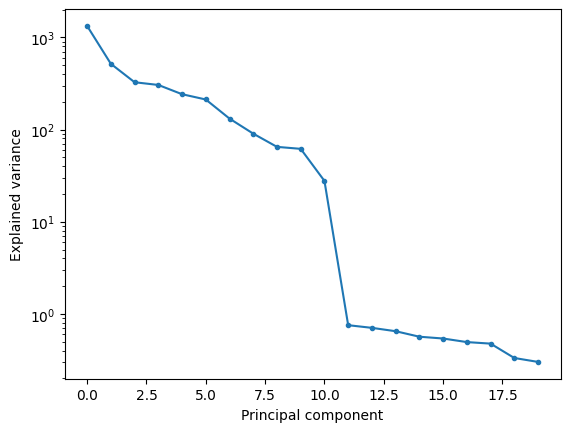

In [33]:
plt.semilogy(pca_module.model.explained_variance_k, '.-')
plt.xlabel("Principal component")
plt.ylabel("Explained variance")
plt.show()